# Topic Modeling 
> **Input:** `corpus_tokenized.json`, `corpus_bert.json`, `corpus_metadata.json`
> **Output:** `topic_labels.csv`, `multilabel_matrix.npy`, `topic_model_comparison.csv`


In [10]:
!pip install gensim pyldavis bertopic sentence-transformers umap-learn hdbscan -q


In [13]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = 'Set2'
print(f'   Gensim : {gensim.__version__}')


   Gensim : 4.3.3


In [15]:
DATA_DIR = '/Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining'
OUTPUT_DIR = '/Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'DATA_DIR   : {os.path.abspath(DATA_DIR)}')
print(f'OUTPUT_DIR : {os.path.abspath(OUTPUT_DIR)}')

required_files = [
    'corpus_tokenized.json',
    'corpus_bert.json',
    'corpus_metadata.json',
]
for fname in required_files:
    fpath = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(fpath)
    size   = f'{os.path.getsize(fpath)/1024:.1f} KB' if exists else '-'
    status = 'ok' if exists else 'no ok FILE TIDAK DITEMUKAN'
    print(f'  {status}  {fname}  ({size})')


DATA_DIR   : /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining
OUTPUT_DIR : /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining
  ok  corpus_tokenized.json  (18540.9 KB)
  ok  corpus_bert.json  (14924.2 KB)
  ok  corpus_metadata.json  (1346.2 KB)


In [16]:
with open(os.path.join(DATA_DIR, 'corpus_tokenized.json'), 'r', encoding='utf-8') as f:
    corpus_tokenized = json.load(f)   

with open(os.path.join(DATA_DIR, 'corpus_bert.json'), 'r', encoding='utf-8') as f:
    corpus_bert = json.load(f)        

with open(os.path.join(DATA_DIR, 'corpus_metadata.json'), 'r', encoding='utf-8') as f:
    metadata = json.load(f)            

df_meta = pd.DataFrame(metadata)

print(f'corpus_tokenized : {len(corpus_tokenized):,} dokumen')
print(f'corpus_bert      : {len(corpus_bert):,} dokumen')
print(f'metadata shape   : {df_meta.shape}')
print(f'Kolom metadata   : {df_meta.columns.tolist()}')
print()
print('Distribusi kategori:')
print(df_meta['kategori'].value_counts().to_frame('jumlah'))


corpus_tokenized : 9,990 dokumen
corpus_bert      : 9,990 dokumen
metadata shape   : (9990, 3)
Kolom metadata   : ['portal', 'kategori', 'judul']

Distribusi kategori:
           jumlah
kategori         
ekonomi      2210
olahraga     2071
politik      1736
hiburan      1459
teknologi     846
otomotif      740
sains         712
lifestyle     216


In [17]:
K_VALUES    = [5, 10, 15, 20]  
RANDOM_SEED = 42

results_comparison = {}
topic_labels_all   = {}

print(f'K values    : {K_VALUES}')
print(f'Random seed : {RANDOM_SEED}')
print(f'Total dokumen untuk diproses: {len(corpus_tokenized):,}')


K values    : [5, 10, 15, 20]
Random seed : 42
Total dokumen untuk diproses: 9,990


---
## 1. LDA — Latent Dirichlet Allocation

**Input:** `corpus_tokenized.json` (list of list of str, sudah di-stem)
**Library:** Gensim
**Evaluasi:** Coherence Score (C_v) + Log Perplexity


In [18]:
id2word = corpora.Dictionary(corpus_tokenized)
print(f'Vocabulary sebelum filter : {len(id2word):,} kata')

# no_below=2 : buang token yang muncul < 2 dokumen
# no_above=0.5: buang token yang muncul di > 50% dokumen
id2word.filter_extremes(no_below=2, no_above=0.5)
print(f'Vocabulary setelah filter  : {len(id2word):,} kata')

corpus_bow = [id2word.doc2bow(doc) for doc in corpus_tokenized]
print(f'Corpus BOW : {len(corpus_bow):,} dokumen')

print()
print('Contoh BOW dokumen-0 (5 token pertama):')
for idx, freq in corpus_bow[0][:5]:
    print(f'  id={idx:4d}  kata={id2word[idx]:15s}  freq={freq}')


Vocabulary sebelum filter : 45,243 kata
Vocabulary setelah filter  : 25,501 kata
Corpus BOW : 9,990 dokumen

Contoh BOW dokumen-0 (5 token pertama):
  id=   0  kata=akibat           freq=1
  id=   1  kata=andal            freq=1
  id=   2  kata=april            freq=1
  id=   3  kata=ardiansyah       freq=1
  id=   4  kata=armada           freq=5


In [20]:
lda_models     = {}
lda_coherence  = {}
lda_perplexity = {}

for k in K_VALUES:
    print(f'>>> Training LDA k={k} ...', end=' ', flush=True)
    lda = LdaModel(
        corpus          = corpus_bow,
        id2word         = id2word,
        num_topics      = k,
        random_state    = RANDOM_SEED,
        passes          = 10,
        alpha           = 'auto',
        eta             = 'auto',
        per_word_topics = True
    )
    lda_models[k] = lda

    cm = CoherenceModel(
        model=lda, texts=corpus_tokenized,
        dictionary=id2word, coherence='c_v'
    )
    lda_coherence[k]  = cm.get_coherence()
    lda_perplexity[k] = lda.log_perplexity(corpus_bow)

    print(f'Coherence={lda_coherence[k]:.4f}  LogPerplexity={lda_perplexity[k]:.4f}')

best_k_lda = max(lda_coherence, key=lda_coherence.get)
print(f'\nBest k = {best_k_lda} (C_v={lda_coherence[best_k_lda]:.4f})')


>>> Training LDA k=5 ... Coherence=0.4489  LogPerplexity=-7.7795
>>> Training LDA k=10 ... Coherence=0.5753  LogPerplexity=-7.7999
>>> Training LDA k=15 ... Coherence=0.5760  LogPerplexity=-8.2812
>>> Training LDA k=20 ... Coherence=0.6116  LogPerplexity=-8.6280

 Best k = 20 (C_v=0.6116)


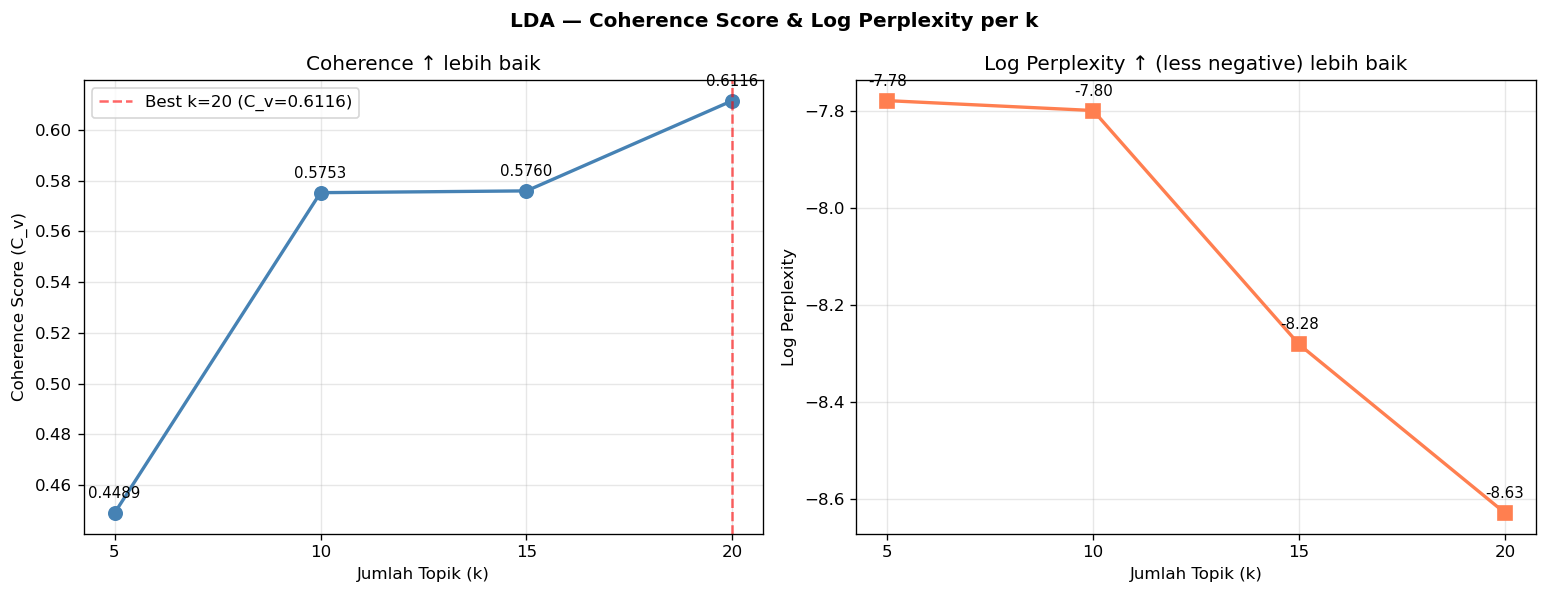


=== HASIL EVALUASI LDA ===
  k= 5 | C_v=0.4489 | LogPerp=-7.7795
  k=10 | C_v=0.5753 | LogPerp=-7.7999
  k=15 | C_v=0.5760 | LogPerp=-8.2812
  k=20 | C_v=0.6116 | LogPerp=-8.6280 ← BEST


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LDA — Coherence Score & Log Perplexity per k', fontweight='bold')

ks  = list(lda_coherence.keys())
cvs = list(lda_coherence.values())
pvs = list(lda_perplexity.values())

axes[0].plot(ks, cvs, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(best_k_lda, color='red', linestyle='--', alpha=0.6,
                label=f'Best k={best_k_lda} (C_v={max(cvs):.4f})')
for k_v, cv_v in zip(ks, cvs):
    axes[0].annotate(f'{cv_v:.4f}', (k_v, cv_v),
                     textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
axes[0].set_xlabel('Jumlah Topik (k)')
axes[0].set_ylabel('Coherence Score (C_v)')
axes[0].set_title('Coherence ↑ lebih baik')
axes[0].set_xticks(ks)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ks, pvs, marker='s', color='coral', linewidth=2, markersize=8)
for k_v, pv_v in zip(ks, pvs):
    axes[1].annotate(f'{pv_v:.2f}', (k_v, pv_v),
                     textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
axes[1].set_xlabel('Jumlah Topik (k)')
axes[1].set_ylabel('Log Perplexity')
axes[1].set_title('Log Perplexity ↑ (less negative) lebih baik')
axes[1].set_xticks(ks)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lda_eval_coherence_perplexity.png'), bbox_inches='tight')
plt.show()

print('\n=== HASIL EVALUASI LDA ===')
for k in K_VALUES:
    mark = ' ← BEST' if k == best_k_lda else ''
    print(f'  k={k:2d} | C_v={lda_coherence[k]:.4f} | LogPerp={lda_perplexity[k]:.4f}{mark}')

results_comparison['LDA'] = {
    'coherence': lda_coherence, 'perplexity': lda_perplexity, 'best_k': best_k_lda
}


In [22]:
best_lda       = lda_models[best_k_lda]
lda_topic_words = {}

print(f'=== TOP WORDS PER TOPIK — LDA k={best_k_lda} ===\n')
for tid in range(best_k_lda):
    words = best_lda.show_topic(tid, topn=10)
    lda_topic_words[tid] = [w for w, _ in words]
    print(f'Topik {tid:2d}: {"  ".join([f"{w}({p:.3f})" for w,p in words])}')

lda_doc_topics = []
for bow in corpus_bow:
    dist  = best_lda.get_document_topics(bow, minimum_probability=0)
    probs = [p for _, p in sorted(dist, key=lambda x: x[0])]
    while len(probs) < best_k_lda:
        probs.append(0.0)
    lda_doc_topics.append(probs[:best_k_lda])

lda_doc_topics = np.array(lda_doc_topics)   # (n_docs, best_k_lda)
lda_dominant   = lda_doc_topics.argmax(axis=1)
topic_labels_all['LDA'] = lda_dominant.tolist()

print(f'\nDistribusi topik dominan:')
print(pd.Series(lda_dominant).value_counts().sort_index().to_frame('jumlah_artikel'))


=== TOP WORDS PER TOPIK — LDA k=20 ===

Topik  0: haji(0.044)  ibadah(0.022)  jamaah(0.018)  allah(0.016)  doa(0.014)  calon(0.010)  islam(0.010)  arab(0.009)  saudi(0.008)  jalan(0.008)
Topik  1: gim(0.018)  open(0.017)  main(0.014)  putri(0.012)  babak(0.012)  unggul(0.011)  malaysia(0.011)  ganda(0.011)  thailand(0.010)  kalah(0.010)
Topik  2: anak(0.031)  presiden(0.025)  prabowo(0.023)  negara(0.011)  digital(0.010)  asean(0.009)  tahun(0.009)  lindung(0.008)  menteri(0.007)  tni(0.007)
Topik  3: main(0.028)  menang(0.021)  tim(0.020)  laga(0.016)  poin(0.014)  musim(0.013)  lawan(0.013)  tanding(0.012)  kalah(0.011)  final(0.010)
Topik  4: balap(0.047)  posisi(0.021)  moto(0.021)  marquez(0.017)  veda(0.011)  finis(0.010)  race(0.009)  poin(0.009)  marc(0.008)  hasil(0.008)
Topik  5: china(0.012)  negara(0.012)  iran(0.011)  pesawat(0.007)  serikat(0.007)  sepakat(0.007)  tinggi(0.006)  amerika(0.006)  lapor(0.006)  terbang(0.006)
Topik  6: usaha(0.017)  kuat(0.014)  industri(0.0

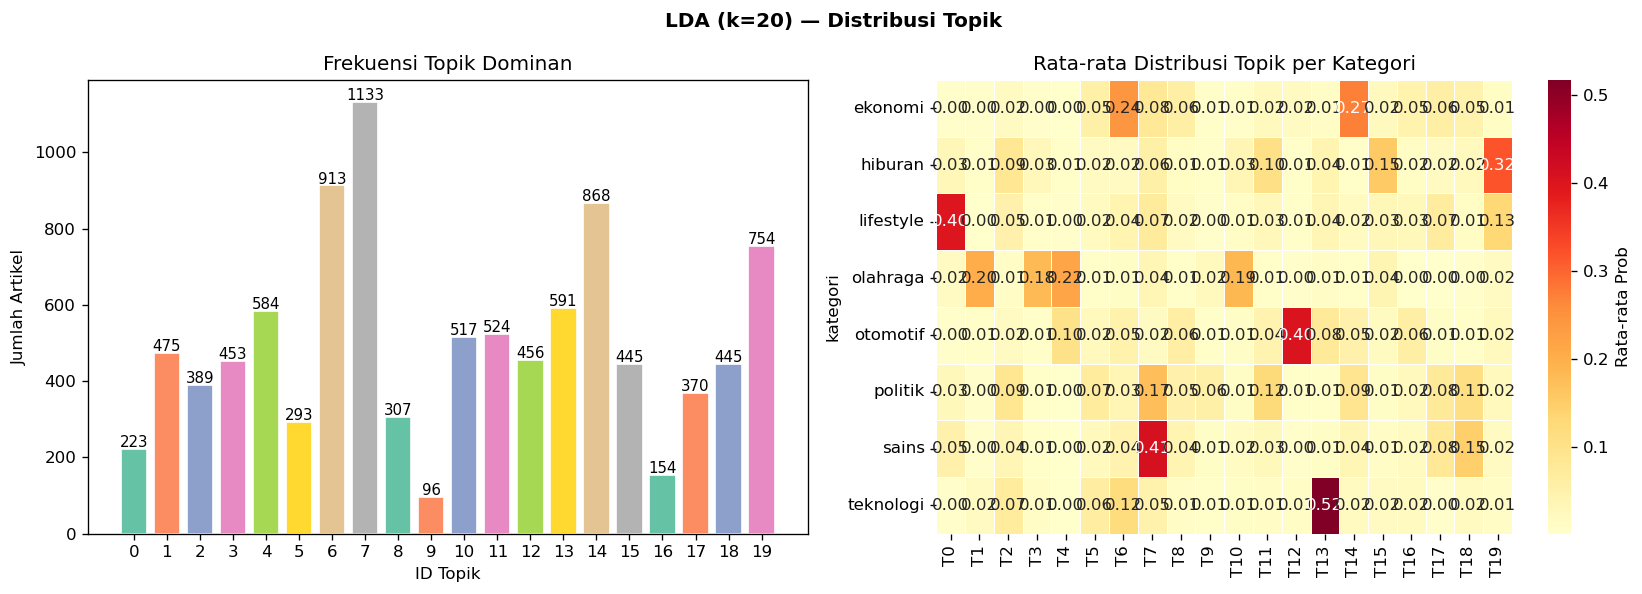

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'LDA (k={best_k_lda}) — Distribusi Topik', fontweight='bold')

topic_counts = pd.Series(lda_dominant).value_counts().sort_index()
colors_lda   = sns.color_palette(PALETTE, best_k_lda)
axes[0].bar(topic_counts.index, topic_counts.values, color=colors_lda, edgecolor='white')
axes[0].set_xlabel('ID Topik')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title('Frekuensi Topik Dominan')
axes[0].set_xticks(range(best_k_lda))
for x, y in zip(topic_counts.index, topic_counts.values):
    axes[0].text(x, y + 5, str(y), ha='center', fontsize=9)

df_lda_vis = df_meta.copy()
for t in range(best_k_lda):
    df_lda_vis[f'topic_{t}'] = lda_doc_topics[:, t]
heatmap_data = df_lda_vis.groupby('kategori')[[f'topic_{t}' for t in range(best_k_lda)]].mean()
heatmap_data.columns = [f'T{t}' for t in range(best_k_lda)]
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Rata-rata Prob'})
axes[1].set_title('Rata-rata Distribusi Topik per Kategori')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lda_topic_distribution.png'), bbox_inches='tight')
plt.show()


## 2. NMF

In [24]:
corpus_joined = [' '.join(doc) for doc in corpus_tokenized]

tfidf_vectorizer = TfidfVectorizer(
    max_df       = 0.85,
    min_df       = 2,
    max_features = 15000,
    ngram_range  = (1, 1)
)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_joined)
tfidf_vocab  = tfidf_vectorizer.get_feature_names_out()

print(f'Shape TF-IDF matrix : {tfidf_matrix.shape}')
print(f'Vocabulary size     : {len(tfidf_vocab):,}')


Shape TF-IDF matrix : (9990, 15000)
Vocabulary size     : 15,000


In [25]:
def compute_coherence_nmf(nmf_model, vectorizer, tokenized_corpus, n_top=10):
    feature_names = vectorizer.get_feature_names_out()
    topics_words  = []
    for topic in nmf_model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top-1:-1]]
        topics_words.append(top_words)
    _d = corpora.Dictionary(tokenized_corpus)
    cm = CoherenceModel(topics=topics_words, texts=tokenized_corpus,
                        dictionary=_d, coherence='c_v')
    return cm.get_coherence(), topics_words


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import numpy as np

corpus_joined = [' '.join(doc) for doc in corpus_tokenized]

tfidf_vectorizer = TfidfVectorizer(
    max_df       = 0.85,
    min_df       = 2,
    max_features = 15000,
    ngram_range  = (1, 1),
    sublinear_tf = True      
)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_joined)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF shape   : {tfidf_matrix.shape}")
print(f"Non-zero       : {tfidf_matrix.nnz:,}")
print(f"Max value      : {tfidf_matrix.max():.4f}")

assert tfidf_matrix.max() > 0, "ERROR: tfidf_matrix semua nol!"
print("✅ tfidf_matrix valid")

TF-IDF shape   : (9990, 15000)
Non-zero       : 1,103,923
Max value      : 0.7123
✅ tfidf_matrix valid


In [44]:
nmf_models    = {}
nmf_coherence = {}

for k in K_VALUES:
    print(f">>> Training NMF k={k} ...", end=" ", flush=True)
    nmf = NMF(
        n_components  = k,
        random_state  = RANDOM_SEED,
        max_iter      = 1000,
        init          = 'nndsvd',    
        solver        = 'cd',        
        beta_loss     = 'frobenius', 
        alpha_W       = 0.0,         
        alpha_H       = 0.0,
        l1_ratio      = 0.0
    )
    nmf.fit(tfidf_matrix)

    # Cek apakah components valid
    max_val = nmf.components_.max()
    if max_val == 0:
        print(f"⚠️  GAGAL (components semua nol), skip k={k}")
        continue

    nmf_models[k] = nmf
    print(f"max_component={max_val:.4f}, n_iter={nmf.n_iter_}", end=" ")

    # Coherence
    coh, _ = compute_coherence_nmf(nmf, tfidf_vectorizer, corpus_tokenized)
    nmf_coherence[k] = coh
    print(f"C_v={coh:.4f}")

if nmf_models:
    best_k_nmf = max(nmf_coherence, key=nmf_coherence.get)
    print(f"\nNMF selesai. Best k={best_k_nmf} (C_v={nmf_coherence[best_k_nmf]:.4f})")
else:
    print("\nSemua k gagal")

>>> Training NMF k=5 ... max_component=1.2028, n_iter=107 C_v=0.8197
>>> Training NMF k=10 ... max_component=1.2361, n_iter=158 C_v=0.7948
>>> Training NMF k=15 ... max_component=1.2495, n_iter=115 C_v=0.8190
>>> Training NMF k=20 ... max_component=1.5451, n_iter=392 C_v=0.8225

NMF selesai. Best k=20 (C_v=0.8225)


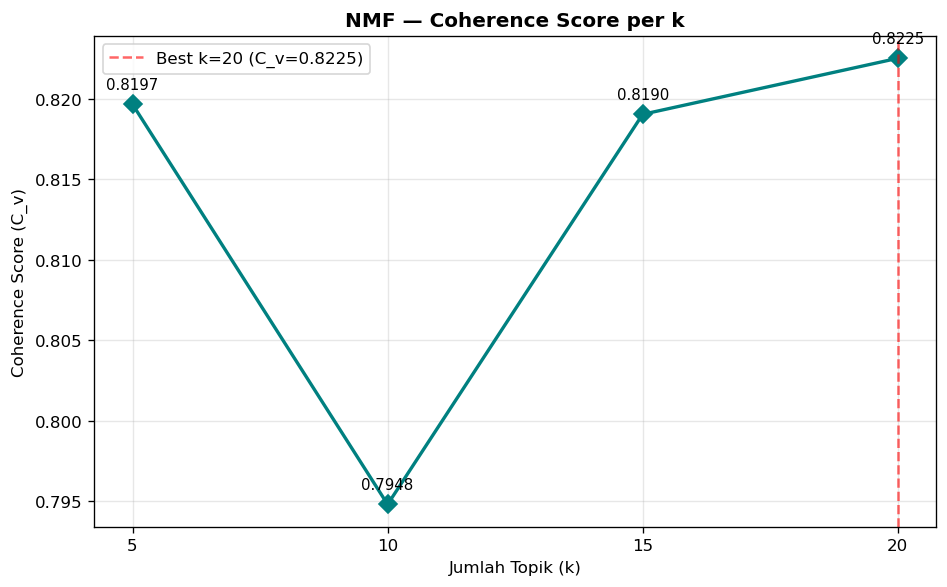


HASIL EVALUASI NMF 
  k= 5 | C_v=0.8197
  k=10 | C_v=0.7948
  k=15 | C_v=0.8190
  k=20 | C_v=0.8225 ← BEST


In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
ks_nmf  = list(nmf_coherence.keys())
cvs_nmf = list(nmf_coherence.values())

ax.plot(ks_nmf, cvs_nmf, marker='D', color='teal', linewidth=2, markersize=8)
ax.axvline(best_k_nmf, color='red', linestyle='--', alpha=0.6,
           label=f'Best k={best_k_nmf} (C_v={max(cvs_nmf):.4f})')
for k_v, cv_v in zip(ks_nmf, cvs_nmf):
    ax.annotate(f'{cv_v:.4f}', (k_v, cv_v),
                textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
ax.set_xlabel('Jumlah Topik (k)')
ax.set_ylabel('Coherence Score (C_v)')
ax.set_title('NMF — Coherence Score per k', fontweight='bold')
ax.set_xticks(ks_nmf)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nmf_eval_coherence.png'), bbox_inches='tight')
plt.show()

print('\nHASIL EVALUASI NMF ')
for k in K_VALUES:
    mark = ' ← BEST' if k == best_k_nmf else ''
    print(f'  k={k:2d} | C_v={nmf_coherence[k]:.4f}{mark}')

results_comparison['NMF'] = {'coherence': nmf_coherence, 'best_k': best_k_nmf}


In [47]:
best_nmf       = nmf_models[best_k_nmf]
feature_names  = tfidf_vectorizer.get_feature_names_out()
nmf_topic_words = {}

print(f'=== TOP WORDS PER TOPIK — NMF k={best_k_nmf} ===\n')
for tid, topic in enumerate(best_nmf.components_):
    top_idx   = topic.argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_idx]
    top_probs = [topic[i] for i in top_idx]
    nmf_topic_words[tid] = top_words
    print(f'Topik {tid:2d}: {chr(32).join([f"{w}({p:.3f})" for w,p in zip(top_words,top_probs)])}')

=== TOP WORDS PER TOPIK — NMF k=20 ===

Topik  0: bangun(0.908) kembang(0.851) kuat(0.837) nasional(0.817) program(0.786) tingkat(0.747) dukung(0.740) ekonomi(0.717) industri(0.673) tumbuh(0.636)
Topik  1: main(0.746) gim(0.709) open(0.707) kalah(0.700) menang(0.693) tanding(0.660) lawan(0.657) babak(0.630) unggul(0.602) laga(0.548)
Topik  2: moto(1.178) marquez(1.114) balap(1.071) marc(0.689) alex(0.621) ducati(0.550) bezzecchi(0.530) martin(0.493) race(0.478) acosta(0.466)
Topik  3: kurban(1.377) hewan(0.985) sapi(0.966) idul(0.891) adha(0.883) ekor(0.579) sembelih(0.510) masjid(0.482) raya(0.466) daging(0.463)
Topik  4: ponsel(0.794) kamera(0.595) perangkat(0.588) pro(0.546) fitur(0.503) baterai(0.493) layar(0.483) luncur(0.421) apple(0.399) phone(0.379)
Topik  5: kendara(1.487) mobil(1.304) listrik(1.169) motor(1.034) pajak(0.728) insentif(0.569) jual(0.543) juta(0.502) unit(0.484) pkb(0.458)
Topik  6: wilayah(0.339) sumatera(0.321) selamat(0.306) ganggu(0.295) israel(0.278) pln(0.

In [48]:
nmf_doc_matrix = best_nmf.transform(tfidf_matrix)   # (n_docs, best_k_nmf)
nmf_dominant   = nmf_doc_matrix.argmax(axis=1)
topic_labels_all['NMF'] = nmf_dominant.tolist()

print(f'Distribusi topik dominan:')
print(pd.Series(nmf_dominant).value_counts().sort_index().to_frame('jumlah_artikel'))

Distribusi topik dominan:
    jumlah_artikel
0              794
1              734
2              362
3              467
4              429
5              504
6              917
7              830
8              825
9              668
10             543
11             535
12             682
13             149
14             111
15             327
16             538
17              73
18             289
19             213


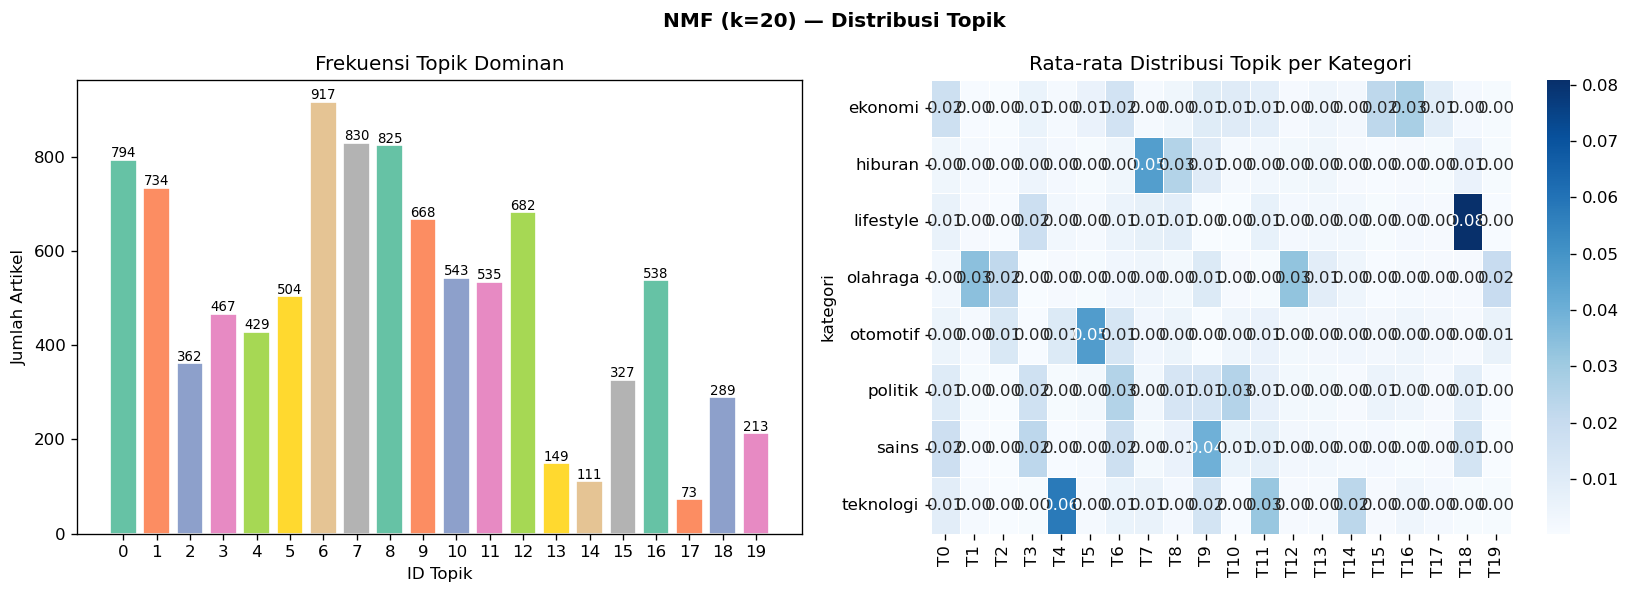

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'NMF (k={best_k_nmf}) — Distribusi Topik', fontweight='bold')

tc_nmf     = pd.Series(nmf_dominant).value_counts().sort_index()
colors_nmf = sns.color_palette(PALETTE, best_k_nmf)
axes[0].bar(tc_nmf.index, tc_nmf.values, color=colors_nmf, edgecolor='white')
axes[0].set_xlabel('ID Topik')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title('Frekuensi Topik Dominan')
axes[0].set_xticks(range(best_k_nmf))
for x, y in zip(tc_nmf.index, tc_nmf.values):
    axes[0].text(x, y + 5, str(y), ha='center', fontsize=8)

df_nmf_vis = df_meta.copy()
hm_nmf = df_nmf_vis.groupby('kategori').apply(
    lambda g: pd.Series(nmf_doc_matrix[g.index].mean(axis=0),
                        index=[f'T{t}' for t in range(best_k_nmf)])
)
sns.heatmap(hm_nmf, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Rata-rata Distribusi Topik per Kategori')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nmf_topic_distribution.png'), bbox_inches='tight')
plt.show()

## 3. BERTopic


In [50]:
EMBEDDING_MODEL  = 'paraphrase-multilingual-MiniLM-L12-v2'
EMBEDDINGS_PATH  = os.path.join(OUTPUT_DIR, 'embeddings_bert.npy')

if os.path.exists(EMBEDDINGS_PATH):
    print(f'Embeddings ditemukan di cache, loading...')
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f'✅ Loaded dari cache. Shape: {embeddings.shape}')
else:
    print(f'Memuat model: {EMBEDDING_MODEL}')
    sentence_model = SentenceTransformer(EMBEDDING_MODEL)
    print(f'Membuat embeddings untuk {len(corpus_bert):,} dokumen...')
    embeddings = sentence_model.encode(
        corpus_bert,
        show_progress_bar = True,
        batch_size        = 32,
        convert_to_numpy  = True
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f'✅ Embeddings selesai & disimpan. Shape: {embeddings.shape}')


Memuat model: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Membuat embeddings untuk 9,990 dokumen...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

✅ Embeddings selesai & disimpan. Shape: (9990, 384)


In [51]:
umap_model = UMAP(
    n_neighbors  = 15,
    n_components = 5,
    min_dist     = 0.0,
    metric       = 'cosine',
    random_state = RANDOM_SEED,
    low_memory   = True      
)

hdbscan_model = HDBSCAN(
    min_cluster_size         = 15,
    metric                   = 'euclidean',
    cluster_selection_method = 'eom',
    prediction_data          = True
)

print('UMAP dan HDBSCAN dikonfigurasi')


UMAP dan HDBSCAN dikonfigurasi


In [52]:
try:
    sentence_model
except NameError:
    sentence_model = SentenceTransformer(EMBEDDING_MODEL)

topic_model = BERTopic(
    embedding_model         = sentence_model,
    umap_model              = umap_model,
    hdbscan_model           = hdbscan_model,
    nr_topics               = 'auto',
    top_n_words             = 10,
    verbose                 = True,
    language                = 'multilingual',
    calculate_probabilities = True,
    min_topic_size          = 15
)

print('Training BERTopic...')
bertopic_topics, bertopic_probs = topic_model.fit_transform(corpus_bert, embeddings)

n_topics_auto = len(set(bertopic_topics)) - (1 if -1 in bertopic_topics else 0)
n_outliers    = list(bertopic_topics).count(-1)

print(f'\nBERTopic selesai')
print(f'   Topik ditemukan : {n_topics_auto}')
print(f'   Outlier (-1)    : {n_outliers} ({n_outliers/len(bertopic_topics)*100:.1f}%)')


2026-06-01 08:58:33,652 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic...


2026-06-01 08:58:51,646 - BERTopic - Dimensionality - Completed ✓
2026-06-01 08:58:51,647 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-01 08:58:55,385 - BERTopic - Cluster - Completed ✓
2026-06-01 08:58:55,385 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-01 08:58:55,984 - BERTopic - Representation - Completed ✓
2026-06-01 08:58:55,985 - BERTopic - Topic reduction - Reducing number of topics
2026-06-01 08:58:56,007 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-01 08:58:56,582 - BERTopic - Representation - Completed ✓
2026-06-01 08:58:56,584 - BERTopic - Topic reduction - Reduced number of topics from 143 to 33



BERTopic selesai
   Topik ditemukan : 32
   Outlier (-1)    : 3455 (34.6%)


In [56]:
topic_model = BERTopic(
    embedding_model = sentence_model,
    umap_model      = umap_model,
    hdbscan_model   = hdbscan_model,
    nr_topics       = K_BERT_TARGET,   
    top_n_words     = 10,
    verbose         = True,
    language        = 'multilingual',
    calculate_probabilities = False,  
    min_topic_size  = 15
)

print('Training BERTopic (dengan nr_topics langsung)...')
bertopic_topics, _ = topic_model.fit_transform(corpus_bert, embeddings)

n_topics_auto = len(set(bertopic_topics)) - (1 if -1 in bertopic_topics else 0)
n_outliers    = list(bertopic_topics).count(-1)

print(f'\nBERTopic selesai')
print(f'   Topik ditemukan : {n_topics_auto}')
print(f'   Outlier (-1)    : {n_outliers} ({n_outliers/len(bertopic_topics)*100:.1f}%)')

2026-06-01 09:11:58,283 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training BERTopic (dengan nr_topics langsung)...


2026-06-01 09:12:09,585 - BERTopic - Dimensionality - Completed ✓
2026-06-01 09:12:09,586 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-01 09:12:09,768 - BERTopic - Cluster - Completed ✓
2026-06-01 09:12:09,768 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-01 09:12:10,413 - BERTopic - Representation - Completed ✓
2026-06-01 09:12:10,414 - BERTopic - Topic reduction - Reducing number of topics
2026-06-01 09:12:10,426 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-01 09:12:11,036 - BERTopic - Representation - Completed ✓
2026-06-01 09:12:11,039 - BERTopic - Topic reduction - Reduced number of topics from 143 to 20



✅ BERTopic selesai
   Topik ditemukan : 19
   Outlier (-1)    : 3455 (34.6%)


In [57]:
print(f'TOP WORDS PER TOPIK — BERTopic (k~{K_BERT_TARGET})\n')
print(topic_model.get_topic_info()[['Topic','Count','Name']].to_string(index=False))

bertopic_topic_words = {}
print('\n--- Detail top words ---')
for tid in sorted(set(bertopic_topics_final)):
    if tid == -1:
        continue
    words = topic_model.get_topic(tid)
    if words:
        bertopic_topic_words[tid] = [w for w, _ in words]
        print(f'Topik {tid:2d}: {"  ".join([f"{w}({p:.3f})" for w,p in words[:8]])}')

bert_topics_for_coh = [
    [w for w, _ in topic_model.get_topic(tid)[:10]]
    for tid in sorted(set(bertopic_topics_final)) if tid != -1
]
_d_bert = corpora.Dictionary(corpus_tokenized)
cm_bert = CoherenceModel(
    topics=bert_topics_for_coh, texts=corpus_tokenized,
    dictionary=_d_bert, coherence='c_v'
)
bert_coherence_score = cm_bert.get_coherence()
print(f'\nBERTopic Coherence Score (C_v) : {bert_coherence_score:.4f}')

results_comparison['BERTopic'] = {
    'coherence': {K_BERT_TARGET: bert_coherence_score},
    'n_topics_auto': n_topics_auto,
    'best_k': K_BERT_TARGET
}


TOP WORDS PER TOPIK — BERTopic (k~20)

 Topic  Count                                 Name
    -1   3455   -1_jakarta_tahun_masyarakat_negara
     0   1308 0_digital_pendidikan_masyarakat_anak
     1   1172          1_marquez_moto_poin_balapan
     2   1059               2_lagu_haji_film_allah
     3    845   3_ekspor_pemerintah_energi_ekonomi
     4    462           4_korban_erin_hukum_pelaku
     5    259            5_ponsel_apple_pro_kamera
     6    247          6_mobil_byd_liter_kendaraan
     7    177      7_pesawat_tni_kapal_penerbangan
     8    165             8_kurban_sapi_hewan_ekor
     9    143              9_saham_indeks_ihsg_tbk
    10    136       10_israel_iran_wni_kemanusiaan
    11    136   11_pln_sumatera_kelistrikan_sistem
    12     93               12_run_jogja_lari_city
    13     89             13_gram_emas_harga_antam
    14     82        14_pengguna_google_fitur_meta
    15     57         15_redeem_kode_mobile_hadiah
    16     46       16_kereta_kecelakaan_ta

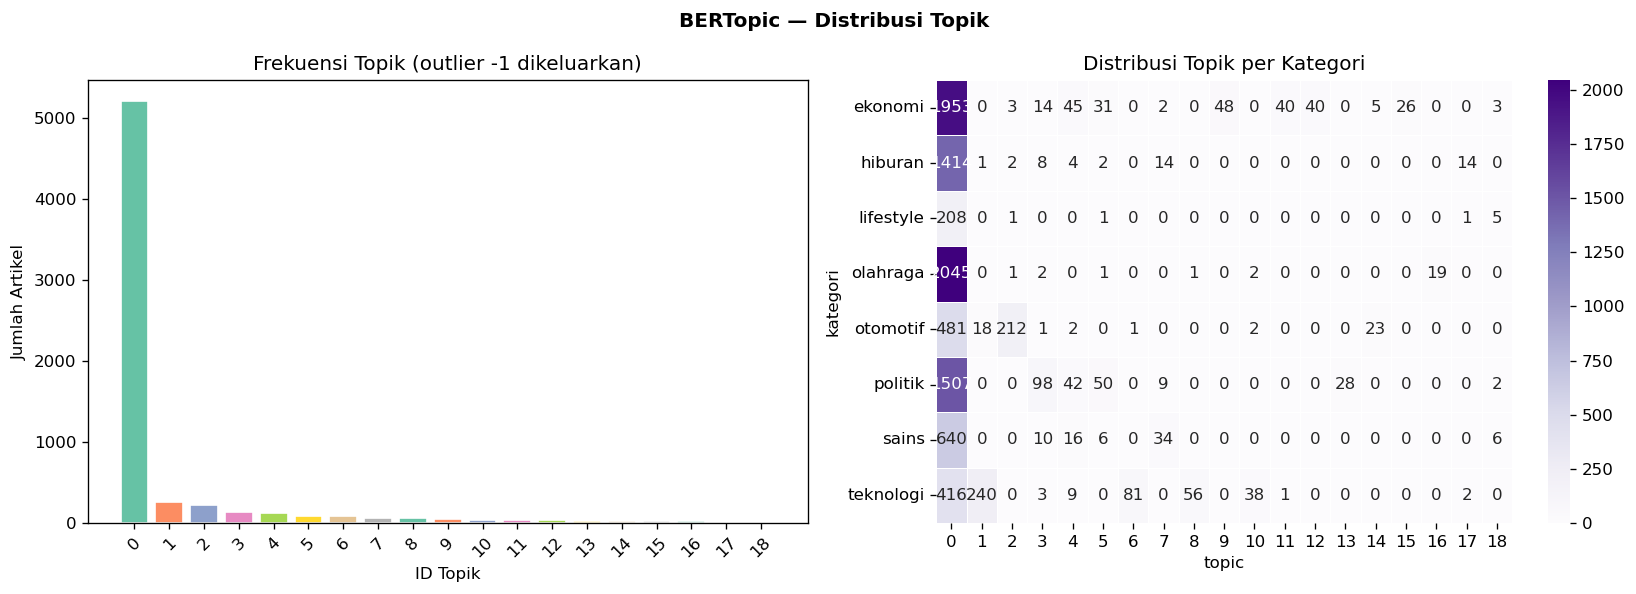

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERTopic — Distribusi Topik', fontweight='bold')

tc_bert = pd.Series(bertopic_topics_final)
tc_bert = tc_bert[tc_bert != -1].value_counts().sort_index()
axes[0].bar(tc_bert.index.astype(str), tc_bert.values,
            color=sns.color_palette(PALETTE, len(tc_bert)), edgecolor='white')
axes[0].set_xlabel('ID Topik')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title('Frekuensi Topik (outlier -1 dikeluarkan)')
axes[0].tick_params(axis='x', rotation=45)

df_bert_vis = df_meta.copy()
df_bert_vis['topic'] = bertopic_topics_final
ct_bert = pd.crosstab(df_bert_vis['kategori'], df_bert_vis['topic'].clip(lower=0))
sns.heatmap(ct_bert, annot=True, fmt='d', cmap='Purples',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Distribusi Topik per Kategori')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bertopic_distribution.png'), bbox_inches='tight')
plt.show()


## Perbandingan Model



In [59]:
rows = []
for k in K_VALUES:
    rows.append({
        'k'            : k,
        'LDA C_v'      : lda_coherence.get(k, np.nan),
        'NMF C_v'      : nmf_coherence.get(k, np.nan),
        'BERTopic C_v' : bert_coherence_score if k == K_BERT_TARGET else np.nan
    })

df_comparison = pd.DataFrame(rows).round(4)

print('=== TABEL PERBANDINGAN COHERENCE SCORE — SKENARIO S1 ===')
print(df_comparison.to_string(index=False))
print()

all_cv = {
    f'LDA     (k={best_k_lda})' : max(lda_coherence.values()),
    f'NMF     (k={best_k_nmf})' : max(nmf_coherence.values()),
    f'BERTopic(k~{K_BERT_TARGET})': bert_coherence_score
}
winner = max(all_cv, key=all_cv.get)
print('--- Best per model ---')
for name, cv in all_cv.items():
    mark = ' ← WINNER' if name == winner else ''
    print(f'  {name} | C_v = {cv:.4f}{mark}')

df_comparison.to_csv(os.path.join(OUTPUT_DIR, 'topic_model_comparison.csv'), index=False)
print(f'\nDisimpan: topic_model_comparison.csv')


=== TABEL PERBANDINGAN COHERENCE SCORE — SKENARIO S1 ===
 k  LDA C_v  NMF C_v  BERTopic C_v
 5   0.4489   0.8197           NaN
10   0.5753   0.7948           NaN
15   0.5760   0.8190           NaN
20   0.6116   0.8225        0.6915

--- Best per model ---
  LDA     (k=20) | C_v = 0.6116
  NMF     (k=20) | C_v = 0.8225 ← WINNER
  BERTopic(k~20) | C_v = 0.6915

Disimpan: topic_model_comparison.csv


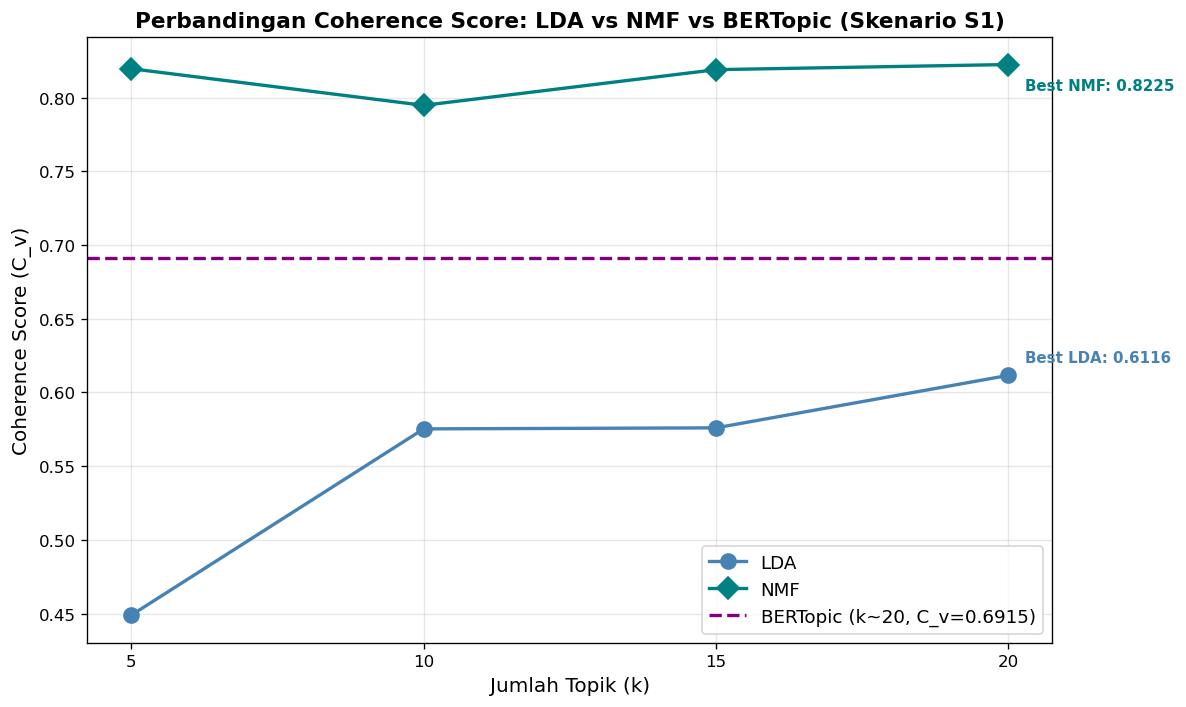

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(K_VALUES, [lda_coherence[k] for k in K_VALUES],
        marker='o', color='steelblue', linewidth=2, markersize=9, label='LDA')
ax.plot(K_VALUES, [nmf_coherence[k] for k in K_VALUES],
        marker='D', color='teal',      linewidth=2, markersize=9, label='NMF')
ax.axhline(bert_coherence_score, color='purple', linewidth=2, linestyle='--',
           label=f'BERTopic (k~{K_BERT_TARGET}, C_v={bert_coherence_score:.4f})')

ax.annotate(f'Best LDA: {max(lda_coherence.values()):.4f}',
            (best_k_lda, lda_coherence[best_k_lda]),
            textcoords='offset points', xytext=(10, 8),
            fontsize=9, color='steelblue', fontweight='bold')
ax.annotate(f'Best NMF: {max(nmf_coherence.values()):.4f}',
            (best_k_nmf, nmf_coherence[best_k_nmf]),
            textcoords='offset points', xytext=(10, -15),
            fontsize=9, color='teal', fontweight='bold')

ax.set_xlabel('Jumlah Topik (k)', fontsize=12)
ax.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax.set_title('Perbandingan Coherence Score: LDA vs NMF vs BERTopic (Skenario S1)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 's1_comparison_coherence.png'), bbox_inches='tight', dpi=150)
plt.show()


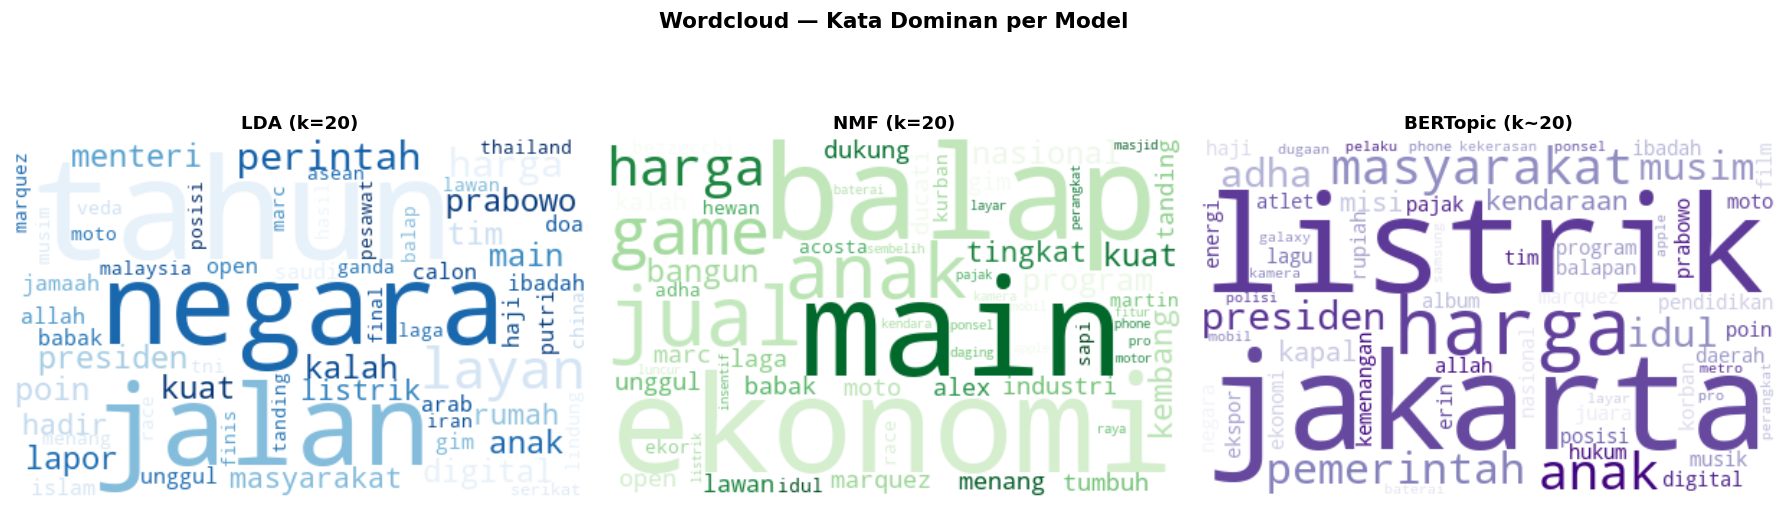

In [61]:
from wordcloud import WordCloud

def make_wc(words, title, ax, cmap='viridis'):
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=60, colormap=cmap, collocations=False)
    wc.generate(' '.join(words * 3))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=11)

all_lda  = [w for ws in lda_topic_words.values() for w in ws]
all_nmf  = [w for ws in nmf_topic_words.values() for w in ws]
all_bert = [w for ws in bertopic_topic_words.values() for w in ws]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Wordcloud — Kata Dominan per Model', fontweight='bold', fontsize=13)
make_wc(all_lda,  f'LDA (k={best_k_lda})',        axes[0], 'Blues')
make_wc(all_nmf,  f'NMF (k={best_k_nmf})',        axes[1], 'Greens')
make_wc(all_bert, f'BERTopic (k~{K_BERT_TARGET})', axes[2], 'Purples')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 's1_wordcloud_comparison.png'), bbox_inches='tight')
plt.show()


In [62]:
df_labels = df_meta.copy()
df_labels['topic_lda']      = topic_labels_all['LDA']
df_labels['topic_nmf']      = topic_labels_all['NMF']
df_labels['topic_bertopic'] = topic_labels_all['BERTopic']

for t in range(best_k_lda):
    df_labels[f'lda_prob_t{t}'] = lda_doc_topics[:, t]

df_labels['bertopic_outlier'] = (df_labels['topic_bertopic'] == -1).astype(int)

print(f'Shape df_labels : {df_labels.shape}')
print()
print(df_labels[['portal','kategori','judul','topic_lda','topic_nmf','topic_bertopic']].head(8).to_string())


Shape df_labels : (9990, 27)

  portal kategori                                                                            judul  topic_lda  topic_nmf  topic_bertopic
0  detik  ekonomi                    VKTR Kirim 30 Bus Listrik ke Transjakarta Sepanjang Kuartal I          6          0               2
1  detik  ekonomi          Batal Berangkat Haji, Purbaya Pakai Duitnya buat Beli Sapi Kurban Jumbo         17          3               0
2  detik  ekonomi  PT DSI Dibentuk, Pemerintah Pede Bisa Genjot Devisa-Dolar AS Balik ke Rp 16.900         14         15               0
3  detik  ekonomi           Investasi Digital China di RI Dinilai Bawa Peluang Sekaligus Tantangan          6          0               0
4  detik  ekonomi                            Dolar AS Nyaris Rp 17.800, Purbaya: Nggak Masuk Akal!         14         16               0
5  detik  ekonomi                                 Beli Hewan Kurban Kena Pajak Nggak? Ini Kata DJP         17          3               0
6  detik  e

In [63]:
THRESHOLD = 0.15   

multilabel_matrix = (lda_doc_topics >= THRESHOLD).astype(int)
n_labels_per_doc  = multilabel_matrix.sum(axis=1)
avg_labels        = n_labels_per_doc.mean()

print(f'=== MULTI-LABEL MATRIX (threshold={THRESHOLD}) ===')
print(f'Shape              : {multilabel_matrix.shape}')
print(f'Rata-rata label/dok: {avg_labels:.2f}')
print(f'Min / Max label    : {n_labels_per_doc.min()} / {n_labels_per_doc.max()}')
print()
print('Distribusi jumlah label per dokumen:')
print(pd.Series(n_labels_per_doc).value_counts().sort_index().to_frame('jumlah_dok'))

if avg_labels < 1.5:
    print('\n⚠️  avg_labels rendah — coba turunkan THRESHOLD (misal: 0.10)')
elif avg_labels > 4.0:
    print('\n⚠️  avg_labels tinggi — coba naikkan THRESHOLD (misal: 0.20)')
else:
    print('\n✅  Distribusi label terlihat wajar')

# Tambahkan ke df_labels
for t in range(best_k_lda):
    df_labels[f'label_t{t}'] = multilabel_matrix[:, t]


=== MULTI-LABEL MATRIX (threshold=0.15) ===
Shape              : (9990, 20)
Rata-rata label/dok: 1.85
Min / Max label    : 1 / 5

Distribusi jumlah label per dokumen:
   jumlah_dok
1        3697
2        4316
3        1780
4         195
5           2

✅  Distribusi label terlihat wajar


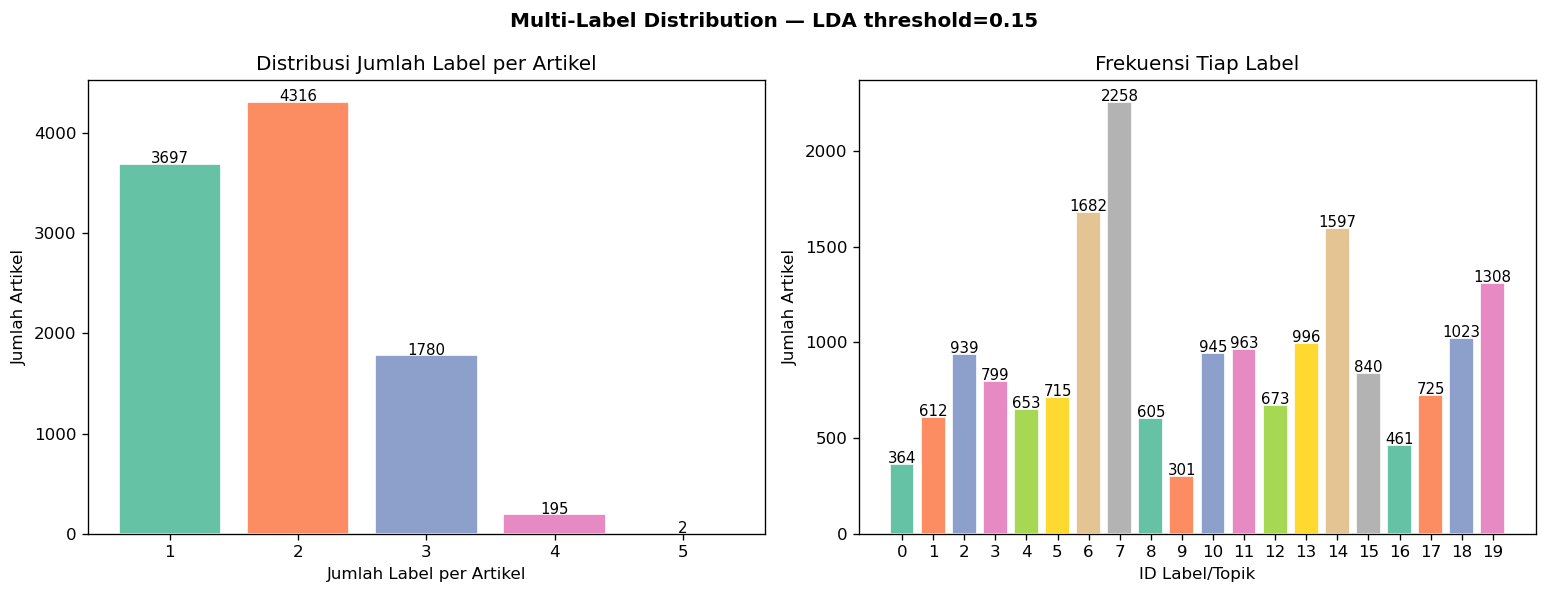

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Multi-Label Distribution — LDA threshold={THRESHOLD}', fontweight='bold')

dist_nlabels = pd.Series(n_labels_per_doc).value_counts().sort_index()
axes[0].bar(dist_nlabels.index, dist_nlabels.values,
            color=sns.color_palette(PALETTE, len(dist_nlabels)), edgecolor='white')
axes[0].set_xlabel('Jumlah Label per Artikel')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title('Distribusi Jumlah Label per Artikel')
for x, y in zip(dist_nlabels.index, dist_nlabels.values):
    axes[0].text(x, y + 5, str(y), ha='center', fontsize=9)

label_freq = multilabel_matrix.sum(axis=0)
axes[1].bar(range(best_k_lda), label_freq,
            color=sns.color_palette(PALETTE, best_k_lda), edgecolor='white')
axes[1].set_xlabel('ID Label/Topik')
axes[1].set_ylabel('Jumlah Artikel')
axes[1].set_title('Frekuensi Tiap Label')
axes[1].set_xticks(range(best_k_lda))
for i, v in enumerate(label_freq):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'multilabel_distribution.png'), bbox_inches='tight')
plt.show()


In [65]:
df_labels.to_csv(os.path.join(OUTPUT_DIR, 'topic_labels.csv'), index=False)
df_labels.to_pickle(os.path.join(OUTPUT_DIR, 'topic_labels.pkl'))
np.save(os.path.join(OUTPUT_DIR, 'multilabel_matrix.npy'), multilabel_matrix)
df_comparison.to_csv(os.path.join(OUTPUT_DIR, 'topic_model_comparison.csv'), index=False)

print('=== OUTPUT TERSIMPAN ===')
print(f'  OUTPUT_DIR : {os.path.abspath(OUTPUT_DIR)}')
print(f'  topic_labels.csv         → {df_labels.shape}')
print(f'  topic_labels.pkl         → versi pickle')
print(f'  multilabel_matrix.npy    → {multilabel_matrix.shape}')
print(f'  embeddings_bert.npy      → {embeddings.shape} (cache embedding)')
print(f'  bertopic_model/          → model BERTopic tersimpan')
print(f'  topic_model_comparison.csv')
print()
print('=== SIAP UNTUK STEP 4: MULTI-LABEL CLASSIFICATION ===')
print(f'  Input : topic_labels.pkl + dataset_preprocessed.pkl')
print(f'  Target: kolom label_t0 ... label_t{best_k_lda-1}')
print(f'  Model : IndoBERT · BiLSTM · CNN · GRU')


=== OUTPUT TERSIMPAN ===
  OUTPUT_DIR : /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining
  topic_labels.csv         → (9990, 47)
  topic_labels.pkl         → versi pickle
  multilabel_matrix.npy    → (9990, 20)
  embeddings_bert.npy      → (9990, 384) (cache embedding)
  bertopic_model/          → model BERTopic tersimpan
  topic_model_comparison.csv

=== SIAP UNTUK STEP 4: MULTI-LABEL CLASSIFICATION ===
  Input : topic_labels.pkl + dataset_preprocessed.pkl
  Target: kolom label_t0 ... label_t19
  Model : IndoBERT · BiLSTM · CNN · GRU


In [66]:
print('=' * 60)
print('RINGKASAN NOTEBOOK TOPIC MODELING')
print('=' * 60)
print(f'Dataset     : {len(corpus_tokenized):,} artikel')
print(f'Kategori    : {df_meta["kategori"].nunique()} | Portal: {df_meta["portal"].nunique()}')
print()
print('--- Skenario S1: Perbandingan Topic Modeling ---')
print(f'LDA      best k={best_k_lda:2d} | C_v = {max(lda_coherence.values()):.4f}')
print(f'NMF      best k={best_k_nmf:2d} | C_v = {max(nmf_coherence.values()):.4f}')
print(f'BERTopic      k~{K_BERT_TARGET:2d} | C_v = {bert_coherence_score:.4f}')
print()
all_cv2 = {
    'LDA':      max(lda_coherence.values()),
    'NMF':      max(nmf_coherence.values()),
    'BERTopic': bert_coherence_score
}
winner2 = max(all_cv2, key=all_cv2.get)
print(f'🏆 Model terbaik     : {winner2}')
print(f'Multi-label threshold: {THRESHOLD}')
print(f'Rata-rata label/dok  : {avg_labels:.2f}')
print('=' * 60)


RINGKASAN NOTEBOOK TOPIC MODELING
Dataset     : 9,990 artikel
Kategori    : 8 | Portal: 6

--- Skenario S1: Perbandingan Topic Modeling ---
LDA      best k=20 | C_v = 0.6116
NMF      best k=20 | C_v = 0.8225
BERTopic      k~20 | C_v = 0.6915

🏆 Model terbaik     : NMF
Multi-label threshold: 0.15
Rata-rata label/dok  : 1.85
